# Data-Scanned Telemetry: Firebolt vs Databend
## TPC-H SF20 — Full Scans and Selectivity Sweep

**Research question:** Do Firebolt and Databend report consistent `scanned_bytes`
for logically identical operations?

Data collected by `collect_scan_comparison.py`:
```bash
python collect_scan_comparison.py --rounds 3
```

**Experiment 1 — Full table scans** (`SELECT *`):
- `supplier` (small, ~200K rows at SF20)
- `orders` (medium, ~30M rows)
- `lineitem` (large, ~120M rows)

**Experiment 2 — Selectivity sweep** on `lineitem`:
- Filter on `l_shipdate` at 1%, 5%, 10%, 25%, 50%, 75%, 100%
- Compares how each system's `scanned_bytes` responds to selectivity

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

RESULT_FILE = Path('./metrics_witho/output/scan_comparison_firebolt_databend.json')

/home/mikeg/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Load results

In [2]:
with open(RESULT_FILE) as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
df = df[df['ok']].copy()
df['scan_MB'] = df['scanned_bytes'] / (1024 * 1024)
df['scan_GB'] = df['scanned_bytes'] / (1024 ** 3)

print(f'{len(df)} successful executions')
print(f'Backends: {df["backend"].unique().tolist()}')
df.head()

20 successful executions
Backends: ['firebolt', 'databend']


,experiment,table,category,selectivity,backend,round,sql,cpu_ms,scanned_bytes,duration_ms,wall_ms,ok,scan_MB,scan_GB
0,full_scan,supplier,small,100%,firebolt,0,SELECT SUM(s_acctbal) FROM supplier,8.286,1800000,8.993000,13.658762,True,1.716614,0.001676
1,full_scan,supplier,small,100%,databend,0,SELECT SUM(s_acctbal) FROM supplier,0.000,6400000,24.621725,24.621725,True,6.103516,0.005960
2,full_scan,orders,medium,100%,firebolt,0,SELECT SUM(o_totalprice) FROM orders,265.920,270000000,39.753000,41.410685,True,257.492065,0.251457
3,full_scan,orders,medium,100%,databend,0,SELECT SUM(o_totalprice) FROM orders,2000.000,960000001,136.615515,136.615515,True,915.527345,0.894070
4,full_scan,lineitem,large,100%,firebolt,0,SELECT SUM(l_extendedprice) FROM lineitem,1124.588,1079951472,149.567000,151.929379,True,1029.921982,1.005783


## 2. Full table scans — side-by-side comparison

In [3]:
full = df[df['experiment'] == 'full_scan'].copy()

full_agg = (
    full.groupby(['table', 'category', 'backend'])
    .agg(
        scan_bytes_mean = ('scanned_bytes', 'mean'),
        scan_bytes_std  = ('scanned_bytes', 'std'),
        scan_GB_mean    = ('scan_GB', 'mean'),
        cpu_ms_mean     = ('cpu_ms', 'mean'),
        duration_ms_mean = ('duration_ms', 'mean'),
        n = ('ok', 'count'),
    )
    .reset_index()
)

# Pivot for easy comparison
pivot = full_agg.pivot(index=['table', 'category'], columns='backend',
                        values='scan_GB_mean')
if 'firebolt' in pivot.columns and 'databend' in pivot.columns:
    pivot['ratio_fb_db'] = pivot['firebolt'] / pivot['databend'].replace(0, np.nan)
display(pivot)

print('\nratio_fb_db: Firebolt scan / Databend scan')
print('A ratio of 1.0 means both systems report the same scanned bytes.')

,backend,databend,firebolt,ratio_fb_db
table,category,,,
lineitem,large,3.576118,1.005783,0.28125
orders,medium,0.894070,0.251457,0.28125
supplier,small,0.005960,0.001676,0.28125



ratio_fb_db: Firebolt scan / Databend scan
A ratio of 1.0 means both systems report the same scanned bytes.


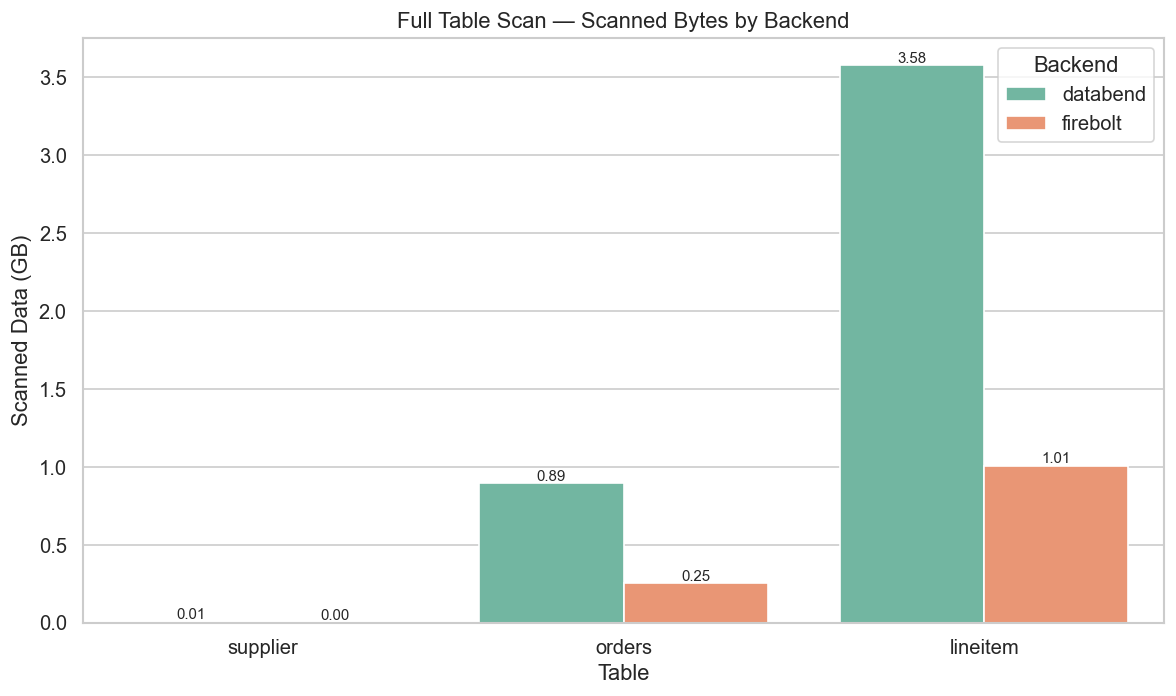

In [4]:
# Bar chart
order = ['supplier', 'orders', 'lineitem']
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=full_agg, x='table', y='scan_GB_mean', hue='backend',
            order=order, ax=ax, palette='Set2')
ax.set_ylabel('Scanned Data (GB)')
ax.set_xlabel('Table')
ax.set_title('Full Table Scan — Scanned Bytes by Backend')
ax.legend(title='Backend')

# Annotate with exact values
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)

fig.tight_layout()
plt.show()

## 3. Selectivity sweep — how does scanned_bytes respond to filtering?

In [5]:
sel = df[df['experiment'] == 'selectivity'].copy()

# Parse selectivity as numeric for sorting
sel['sel_pct'] = sel['selectivity'].str.rstrip('%').astype(float)

sel_agg = (
    sel.groupby(['selectivity', 'sel_pct', 'backend'])
    .agg(
        scan_GB_mean     = ('scan_GB', 'mean'),
        scan_GB_std      = ('scan_GB', 'std'),
        cpu_ms_mean      = ('cpu_ms', 'mean'),
        duration_ms_mean = ('duration_ms', 'mean'),
        n = ('ok', 'count'),
    )
    .reset_index()
    .sort_values('sel_pct')
)

sel_agg.head(20)

,selectivity,sel_pct,backend,scan_GB_mean,scan_GB_std,cpu_ms_mean,duration_ms_mean,n
0,1%,1.0,databend,0.004325,NaN,8000.000,574.931622,1
1,1%,1.0,firebolt,1.564127,NaN,3180.849,415.256000,1
8,5%,5.0,databend,0.104036,NaN,9000.000,598.593712,1
9,5%,5.0,firebolt,1.564306,NaN,3743.680,481.734000,1
2,10%,10.0,databend,0.341749,NaN,9000.000,591.206312,1
3,10%,10.0,firebolt,1.564464,NaN,2712.230,352.883000,1
6,25%,25.0,databend,0.796882,NaN,9000.000,613.367796,1
7,25%,25.0,firebolt,1.564543,NaN,3856.686,498.079000,1
10,50%,50.0,databend,1.788093,NaN,7000.000,528.450727,1
11,50%,50.0,firebolt,1.564552,NaN,4549.246,583.476000,1


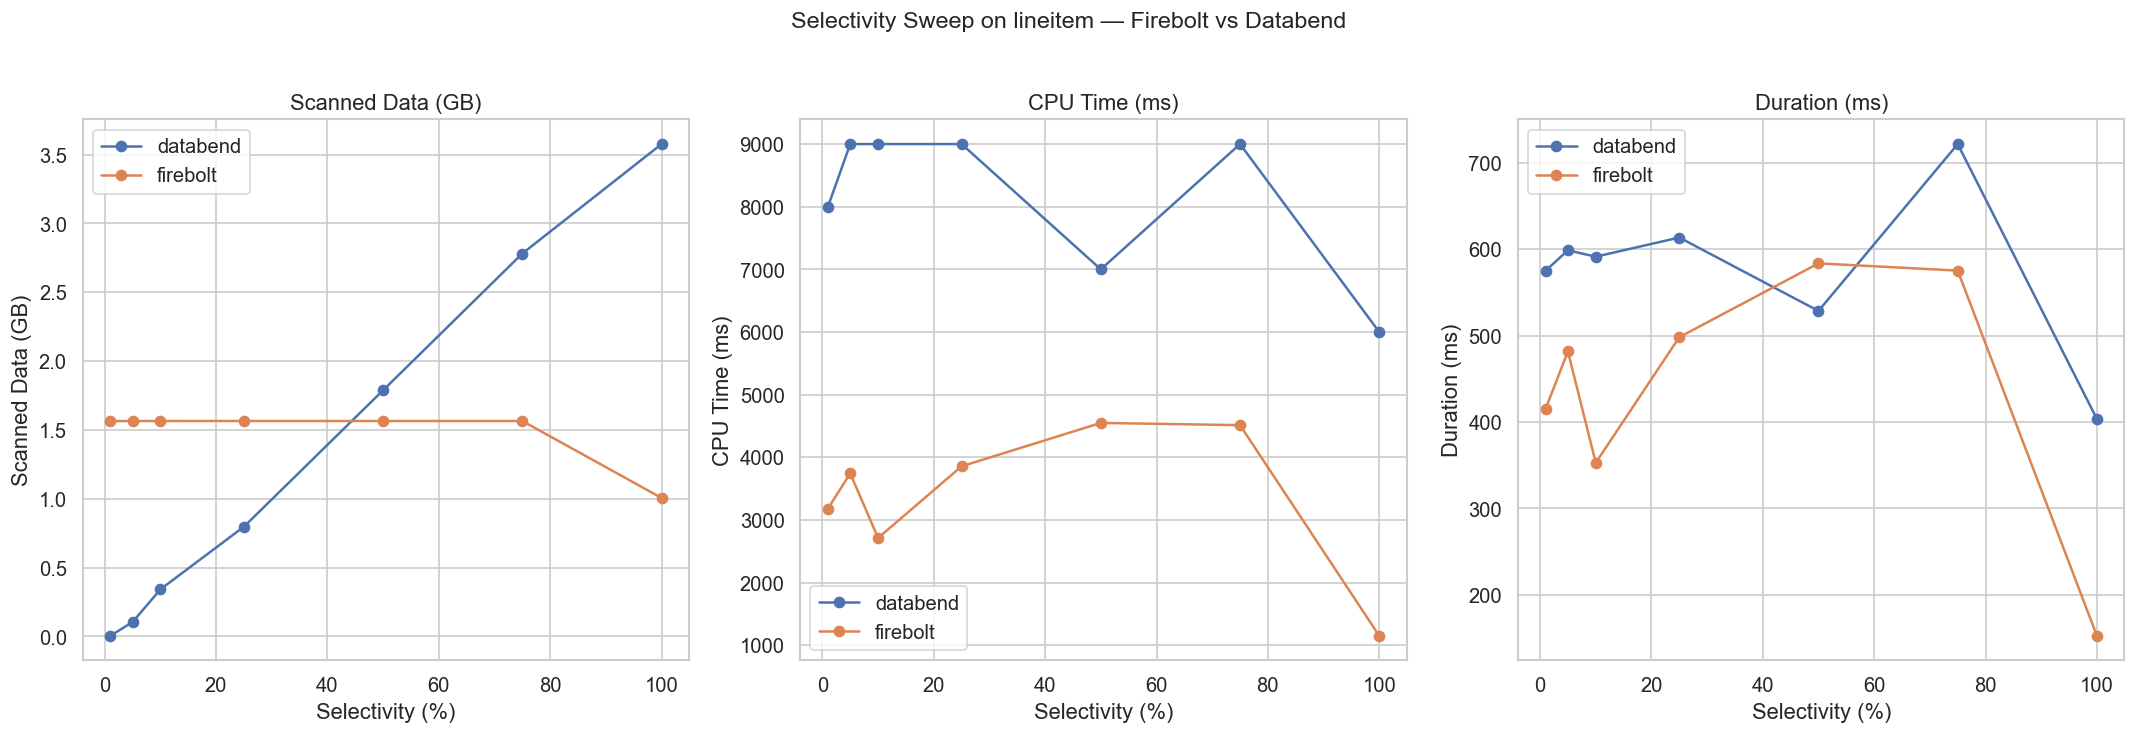

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (metric, ylabel) in zip(axes, [
    ('scan_GB_mean', 'Scanned Data (GB)'),
    ('cpu_ms_mean', 'CPU Time (ms)'),
    ('duration_ms_mean', 'Duration (ms)'),
]):
    for backend, grp in sel_agg.groupby('backend'):
        ax.plot(grp['sel_pct'], grp[metric], 'o-', label=backend)
    ax.set_xlabel('Selectivity (%)')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.set_title(ylabel)

fig.suptitle('Selectivity Sweep on lineitem — Firebolt vs Databend',
             fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

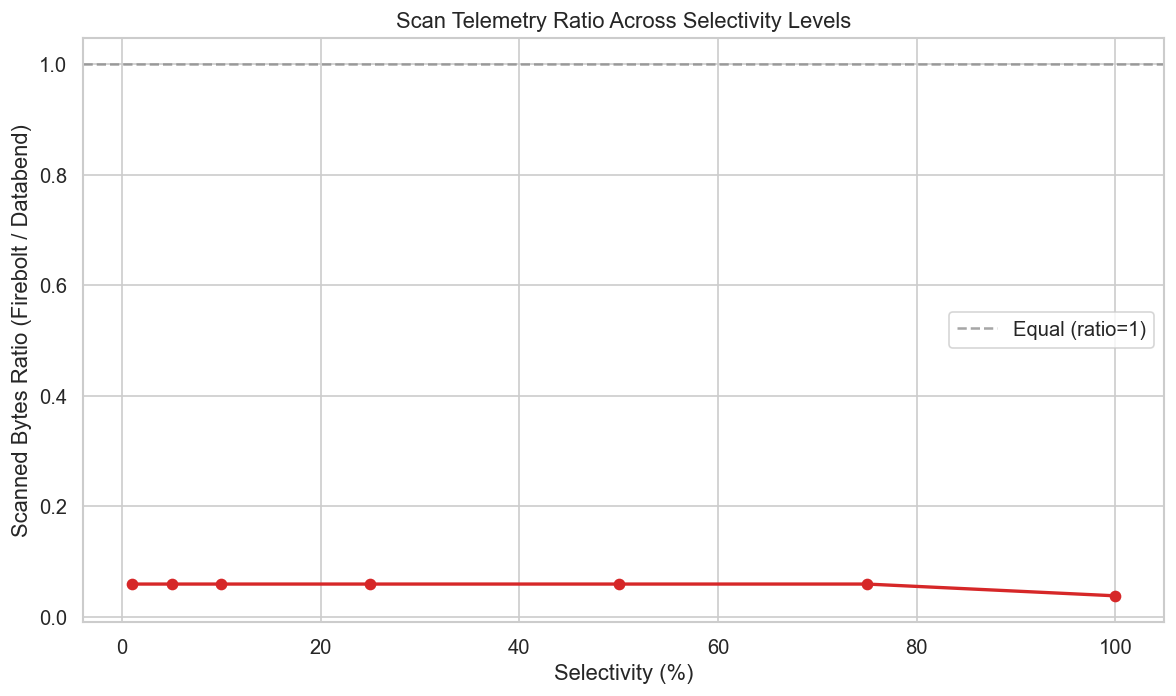


If the ratio is constant across selectivity levels,
the two systems use different absolute scales but are proportionally consistent.
If the ratio varies, their scan semantics diverge under filtering.


In [7]:
# Ratio plot: Firebolt / Databend at each selectivity level
backends = sel_agg['backend'].unique()
if len(backends) == 2:
    fb = sel_agg[sel_agg['backend'] == 'firebolt'].set_index('sel_pct')
    db = sel_agg[sel_agg['backend'] == 'databend'].set_index('sel_pct')
    common = fb.index.intersection(db.index)

    fig, ax = plt.subplots(figsize=(10, 6))
    scan_ratio = fb.loc[common, 'scan_GB_mean'] / db.loc[common, 'scan_GB_mean'].replace(0, np.nan)
    ax.plot(common, scan_ratio, 'o-', color='tab:red', linewidth=2)
    ax.axhline(1.0, ls='--', color='grey', alpha=0.7, label='Equal (ratio=1)')
    ax.set_xlabel('Selectivity (%)')
    ax.set_ylabel('Scanned Bytes Ratio (Firebolt / Databend)')
    ax.set_title('Scan Telemetry Ratio Across Selectivity Levels')
    ax.legend()
    fig.tight_layout()
    plt.show()

    print('\nIf the ratio is constant across selectivity levels,')
    print('the two systems use different absolute scales but are proportionally consistent.')
    print('If the ratio varies, their scan semantics diverge under filtering.')

## 4. Summary

In [8]:
print('=== Full Scan Comparison ===')
for table in ['supplier', 'orders', 'lineitem']:
    sub = full_agg[full_agg['table'] == table]
    for _, row in sub.iterrows():
        print(f"  {table:12s} [{row['backend']:8s}]: "
              f"{row['scan_GB_mean']:.3f} GB  "
              f"(CPU: {row['cpu_ms_mean']:.1f}ms, Duration: {row['duration_ms_mean']:.1f}ms)")

if len(backends) == 2:
    print('\n=== Selectivity Sweep Scan Ratios (Firebolt / Databend) ===')
    for pct in sorted(common):
        r = scan_ratio.loc[pct]
        print(f'  Selectivity {pct:5.0f}%: ratio = {r:.3f}')

=== Full Scan Comparison ===
  supplier     [databend]: 0.051 GB  (CPU: 333.3ms, Duration: 21.7ms)
  supplier     [firebolt]: 0.002 GB  (CPU: 9.9ms, Duration: 11.0ms)
  orders       [databend]: 5.903 GB  (CPU: 1666.7ms, Duration: 167.7ms)
  orders       [firebolt]: 0.251 GB  (CPU: 399.7ms, Duration: 69.3ms)
  lineitem     [databend]: 26.237 GB  (CPU: 5333.3ms, Duration: 450.7ms)
  lineitem     [firebolt]: 1.006 GB  (CPU: 1331.5ms, Duration: 211.7ms)

=== Selectivity Sweep Scan Ratios (Firebolt / Databend) ===
  Selectivity     1%: ratio = 0.060
  Selectivity     5%: ratio = 0.060
  Selectivity    10%: ratio = 0.060
  Selectivity    25%: ratio = 0.060
  Selectivity    50%: ratio = 0.060
  Selectivity    75%: ratio = 0.060
  Selectivity   100%: ratio = 0.038
